In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from scipy.special import gamma

import numba

from lattice import Graphene


from matplotlib.patches import Polygon


import matplotlib.pyplot as plt

import numpy as np
from scipy.special import gamma
from scipy.sparse.linalg import expm_multiply
from scipy.sparse import bmat, diags, block_diag

import numba
from lattice import Graphene

from simulation import System, Eletric_field, Leg
from simulation import add_atom_to_hamiltonian, time_evolution

from utils import draw_basis_vectors, draw_electric_field, annotate_electric_field_text, separate_each_lattice, plot_graphene

In [2]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Avenir', 'DejaVu Sans', 'Lucida Grande', 'Verdana']
plt.rcParams['font.size'] = 25
plt.rcParams['axes.labelsize'] = 20
plt.rcParams['xtick.labelsize'] = 30  # x-axis tick labels
plt.rcParams['ytick.labelsize'] = 30 

<>:29: SyntaxWarning: invalid escape sequence '\d'
<>:29: SyntaxWarning: invalid escape sequence '\d'
/var/folders/q3/1z3g104x46n7562_5r_mvpl80000gn/T/ipykernel_71188/3681138864.py:29: SyntaxWarning: invalid escape sequence '\d'
  """


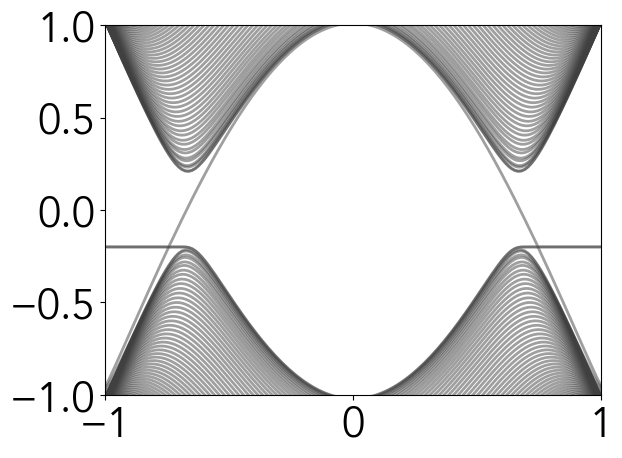

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh

def compute_positions_along_direction_a1(lattice):
  NMAX = lattice.nmax
  a1 = lattice.a1
  a2 = lattice.a2
  d1 = lattice.d1

  m = np.arange(-(NMAX//2), NMAX//2)
  
  na_line = []
  nb_line = []

  n = 0.
  for mm in m:
    ra = mm * a1

    na_line.append(ra)

    rb = mm * a1 + d1
    nb_line.append(rb)

  return np.array(na_line).T, np.array(nb_line).T


def compute_positions_along_line(lattice):
  """
    Computes real lattice positions for sites that lie n a line at y = 0. The
    positions that fullfil such a thing are giving by

    $R_a = n a_1 + m a_2$, such that $n = -2m$ and
    $R_b = n a_1 + m a_2 + \delta$, such that $n =1 -2m$
  """
  NMAX = lattice.nmax
  a1 = lattice.a1
  a2 = lattice.a2
  d1 = lattice.d1

  m = np.arange(-(NMAX//2), NMAX//2)

  na_line = []
  nb_line = []

  for mm in m:
    n = - 2 * mm
    if n in m:
      ra = n * a1 + mm * a2
      na_line.append(ra)
  
    n = 1 - 2 * mm
    if n in m:
      rb = n * a1 + mm * a2 + d1
      nb_line.append(rb)

  return np.array(na_line).T, np.array(nb_line).T


# def Hrm(diagonal, v, w, N):
#     """Open-boundary Rice-Mele Hamiltonian with N unit cells (2N sites).
#     eps0 is the full sublattice energy gap (onsites = +/- eps0/2)."""
#     # diagonal[0] = 1e5
#     # diagonal[-1] = 1e5
#     H  = np.diag(diagonal/2)
#     H += np.diag([v]*N,          k=N)       # intracell bonds
#     H += np.diag([0]+[w]*(N-1)+[0], k=N-1)  # intercell bonds
#     return H + H.T

def Hrm(diag_a, diag_b, v, w, N):
    # Diagonal blocks
    DA = np.diag(diag_a)
    DB = np.diag(diag_b)

    # Off-diagonal block (A → B)
    T = np.zeros((N, N))

    # intracell
    for i in range(N):
        T[i, i] = v

    # intercell
    for i in range(N-1):
        T[i+1, i] = w

    # Full Hamiltonian
    H = np.block([
        [DA,          T],
        [T.conj().T, DB]
    ])

    return H


def spectrum_vs_k(N_cells, lattice, Nk=400):
    """Return k grid and array of shape (Nk, 2N) with eigenvalues."""
    k_vals = np.linspace(-np.pi, np.pi, Nk)
    na, nb = compute_positions_along_direction_a1(lattice)

    # The number of a sites should give the number of unit cells for the 
    # Rice Mele
    N_cells = na.shape[1]

    spec   = np.empty((Nk, 2*N_cells))
    states = np.empty((Nk, 2*N_cells, 2*N_cells), dtype=float)  # real H → real vecs



    diag_a = lattice.delta_0 * np.tanh(na[0]/lattice.lambd)
    diag_b = -lattice.delta_0 * np.tanh(nb[0]/lattice.lambd)
    # diagonal = np.hstack([diag_a, diag_b])

    # diag_a[0] = 1e3
    # diag_b[-1] = 1e3
    for i, k in enumerate(k_vals):
        v = 2*lattice.J*np.cos(k/2)
        w = lattice.J                 # k-dependent intercell hopping
        H = Hrm(diag_a, diag_b, v, w, N_cells)              # pass 2*delta because Hrm uses eps0/2
        spec[i], states[i] = eigh(H)
    return k_vals, spec, states


N     = 100     # Number of sites for each sublattice
Nk    = 150     # k-resolution
LAMBDA = 4
DELTA = 0.2

latt = Graphene(nmax=N, delta_0=DELTA, lambda_0=LAMBDA, pbc="y")

na, nb = latt.n_real_pos

k1, spectrum, states = spectrum_vs_k(N, latt, Nk=Nk)

fig, ax = plt.subplots()
ax.plot(k1 /np.pi, spectrum, color='0.25', lw=2, alpha=0.5, ms=0.8, rasterized=True)
ax.set_xlim(-1,1)
# ax.set_xticks([-1, K6[1]/np.pi , 0, K5[1]/np.pi, 1])
# ax.set_yticks([-1, -DELTA , 0, DELTA, 1])
# ax.set_xticklabels([-1, None, 0, None, 1])
# ax.set_yticklabels([-1, None, 0, None, 1])

ax.set_ylim(-1, 1) 

# ax.axhline(-DELTA, linestyle='dashed', color='red')
# ax.set_xlabel('$k_y$')
# ax.set_ylabel('Spectrum')


plt.show()

In [4]:
def join_arrays_interchange(x1, x2):
    return np.stack([x1, x2], axis=0).T.flatten()

The energies are: [-0.08824712 -0.0510595  -0.01426953  0.02210506  0.05804688  0.09353884
  0.09353884  0.05804688  0.02210506 -0.01426953 -0.0510595  -0.08824712]. 
The k's are: [-2.21387402 -2.17170499 -2.12953596 -2.08736693 -2.0451979  -2.00302887
  2.00302887  2.0451979   2.08736693  2.12953596  2.17170499  2.21387402]
We are choosing the state with the energy = -0.0882 and k=-2.2139


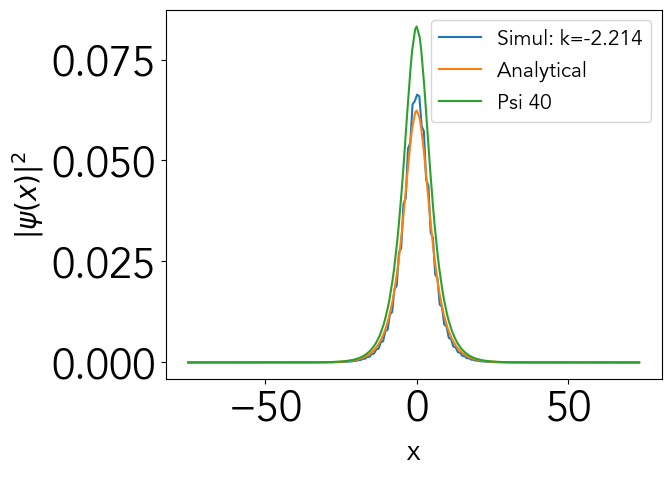

In [5]:
vf = 3/2
idxs = np.where(np.isclose(spectrum , 0, atol=1e-1))

energies = spectrum[idxs]
ks = k1[idxs[0]]

print(f"The energies are: {energies}. \nThe k's are: {ks}")

i = 0

print(f"We are choosing the state with the energy = {energies[i]:.4f} and k={ks[i]:.4f}")

state = states[idxs[0], :, idxs[1]][i]
nn = len(state)

xmin = min(na[0].min(), nb[0].min())
xmax = max(na[0].max(), nb[0].max())
x = np.linspace(xmin, xmax, len(state))


psi = join_arrays_interchange(state[:nn//2], state[nn//2:])
# psi = join_arrays_interchange(state[(nn//2):], state[:nn//2])
# 
m = np.arange(-(N//2), N//2)
xa = 3 * m / 2

# vec(delta) = -0.5 (1, sqrt(3))
xb = xa - 1/2
plt.plot(x, np.abs(psi) ** 2, label=f"Simul: k={ks[0]:.3f}")
x = join_arrays_interchange(xb, xa)

beta = DELTA * LAMBDA / vf

# NN2  = gamma(beta + 1/2) / gamma(beta) / LAMBDA / np.sqrt(np.pi) 
psi_analytic_a = (1/np.cosh(xa/LAMBDA)) ** (beta)
psi_analytic_b = (1/np.cosh(xb/LAMBDA)) ** (beta)

psi_analytic = join_arrays_interchange(psi_analytic_b, psi_analytic_a)

v = (1/np.cosh(x/LAMBDA)) ** (2*beta)
A = 1/np.sqrt(np.sum(v))

psi_analytic *= A
plt.plot(x,np.abs(psi_analytic)**2, label="Analytical")

# plt.plot(np.abs(states[idxs][1]) ** 2, linestyle="dashed", label=f"k={ks[1]:.3f}")

plt.xlabel("x")
plt.ylabel(r"$|\psi(x)|^2$")


NN = np.sqrt(gamma(beta + 1/2) / gamma(beta) / LAMBDA / np.sqrt(np.pi))
psi_40 = NN * (1/np.cosh(x/LAMBDA)) ** beta


plt.plot(x, np.abs(psi_40) ** 2, label="Psi 40")
# plt.ylim(0, 0.0005)
# plt.yscale("log")
# plt.xscale("log")
plt.legend(fontsize=15)
